In [8]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

# Qrafiklərin üslubunu peşəkar görünüşə gətiririk
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

print(' Kitabxanalar uğurla yükləndi')

 Kitabxanalar uğurla yükləndi


In [9]:
display(df)

,Job Title,Company,Location,Skills / Tech Stack,Post Date,Skills_Count
0,Administrative Assistant,TIMBERTEK,"دبي, دبي الإمارات العربية المتحدة","data entry, virtual assistant, teaching, educa...",2026-08-04,20
1,Assistant Area Sales & Customer Manager,Unilever,"Navi Mumbai, Navi Mumbai, Maharashtra, India","data entry, virtual assistant, teaching, educa...",2026-08-03,10
2,Customer Support,Re Lytics Hires,"عسير, عسير السعودية","data entry, virtual assistant, teaching, educa...",2026-08-03,20
3,Entry Level Administrative Assistant,Re Lytics Hires,"أبو ظبي, أبو ظبي أبو ظبي الإمارات العربية المتحدة","data entry, virtual assistant, teaching, educa...",2026-08-03,15
4,Data Entry & Administrative Assistant,Re Lytics Hires,"أبو ظبي, أبو ظبي أبو ظبي الإمارات العربية المتحدة","data entry, virtual assistant, teaching, educa...",2026-08-03,18
...,...,...,...,...,...,...
95,Designer,Cats Protection,"Chelwood Gate,","analyst, customer support, marketing, travel, ...",2026-06-30,22
96,Data Entry Specialist Assistant Administrator,Recruit Lytics Hiring,"Hong Kong, Hong Kong, Hong Kong SAR","virtual assistant, education, customer support...",2026-06-26,11
97,Nurse Advice Swing Shift 5a 10a 10p 5a CST,IntellaTriage,"United States,","hr, virtual assistant, exec, customer support,...",2026-06-24,36
98,Director of Procurement,Kardion,"Remote,","data entry, infosec, customer support, dev, ex...",2026-06-24,25


In [10]:
df = pd.read_csv('remote_job_market_data.csv')

print(f'• Cəmi Sətir Sayı: {df.shape[0]}')
print(f'• Cəmi Sütun Sayı: {df.shape[1]}\n')

# Sütunlar haqqında ətraflı cədvəl
audit_df = pd.DataFrame(
    {
        'Column Name': df.columns,
        'Data Type': df.dtypes.values,
        'Non-Null Count': df.notnull().sum().values,
        'Null Count': df.isnull().sum().values,
        'Null Ratio (%)': (df.isnull().sum() / len(df) * 100).round(2).values,
        'Unique Values': [df[col].nunique() for col in df.columns],
    }
)
display(audit_df)

print(f'\n Təkrarlanan (Duplicate) sətir sayısı: {df.duplicated().sum()}')

• Cəmi Sətir Sayı: 100
• Cəmi Sütun Sayı: 5



,Column Name,Data Type,Non-Null Count,Null Count,Null Ratio (%),Unique Values
0,Job Title,object,100,0,0.0,83
1,Company,object,100,0,0.0,77
2,Location,object,100,0,0.0,66
3,Skills / Tech Stack,object,100,0,0.0,82
4,Post Date,object,100,0,0.0,30



 Təkrarlanan (Duplicate) sətir sayısı: 0


In [11]:
# 1. Bacarıqları massivə çevirib təmizləyirik (NLP parsing)
skills_series = (
    df['Skills / Tech Stack']
    .dropna()
    .astype(str)
    .str.split(',')
    .explode()
    .str.strip()
    .str.lower()
)
# 2. Hər vakansiya üçün tələb olunan bacarıq sayını hesablayıb yeni sütun yaradırıq
df['Skills_Count'] = df['Skills / Tech Stack'].apply(
    lambda x: len([s.strip() for s in str(x).split(',')]) if pd.notnull(x) else 0
)
display(df[['Job Title', 'Company', 'Skills_Count']])

,Job Title,Company,Skills_Count
0,Administrative Assistant,TIMBERTEK,20
1,Assistant Area Sales & Customer Manager,Unilever,10
2,Customer Support,Re Lytics Hires,20
3,Entry Level Administrative Assistant,Re Lytics Hires,15
4,Data Entry & Administrative Assistant,Re Lytics Hires,18
...,...,...,...
95,Designer,Cats Protection,22
96,Data Entry Specialist Assistant Administrator,Recruit Lytics Hiring,11
97,Nurse Advice Swing Shift 5a 10a 10p 5a CST,IntellaTriage,36
98,Director of Procurement,Kardion,25


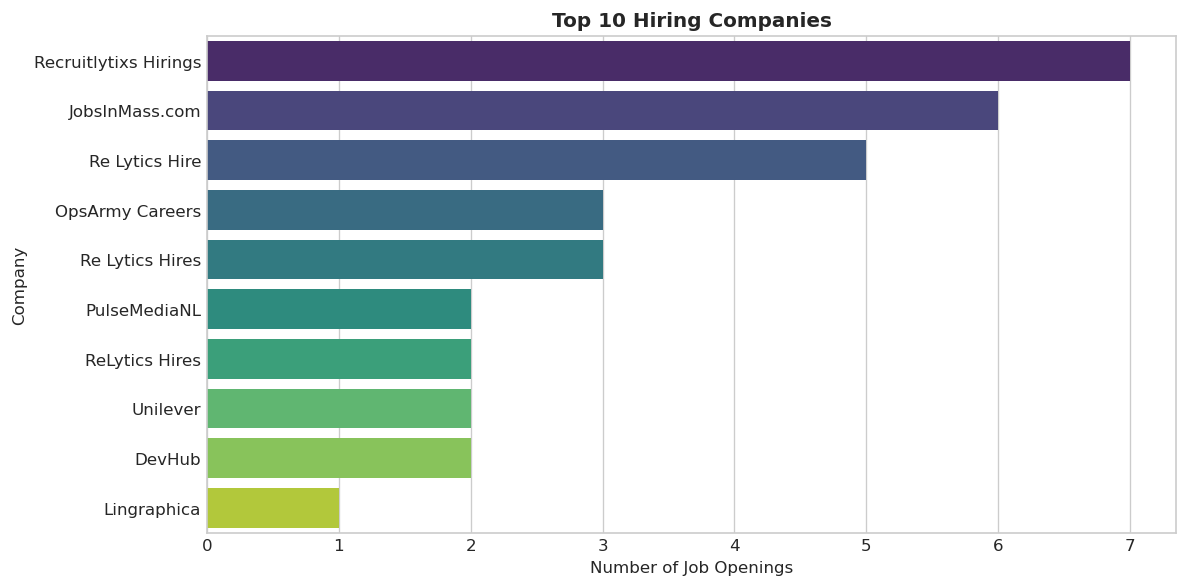

In [12]:
# 1. Top 10 Şirkət
plt.figure(figsize=(10, 5))
top_companies = df['Company'].value_counts().head(10)

sns.barplot(
    x=top_companies.values, y=top_companies.index, palette='viridis'
)
plt.title('Top 10 Hiring Companies', fontsize=12, fontweight='bold')
plt.xlabel('Number of Job Openings')
plt.ylabel('Company')
plt.tight_layout()
plt.show()

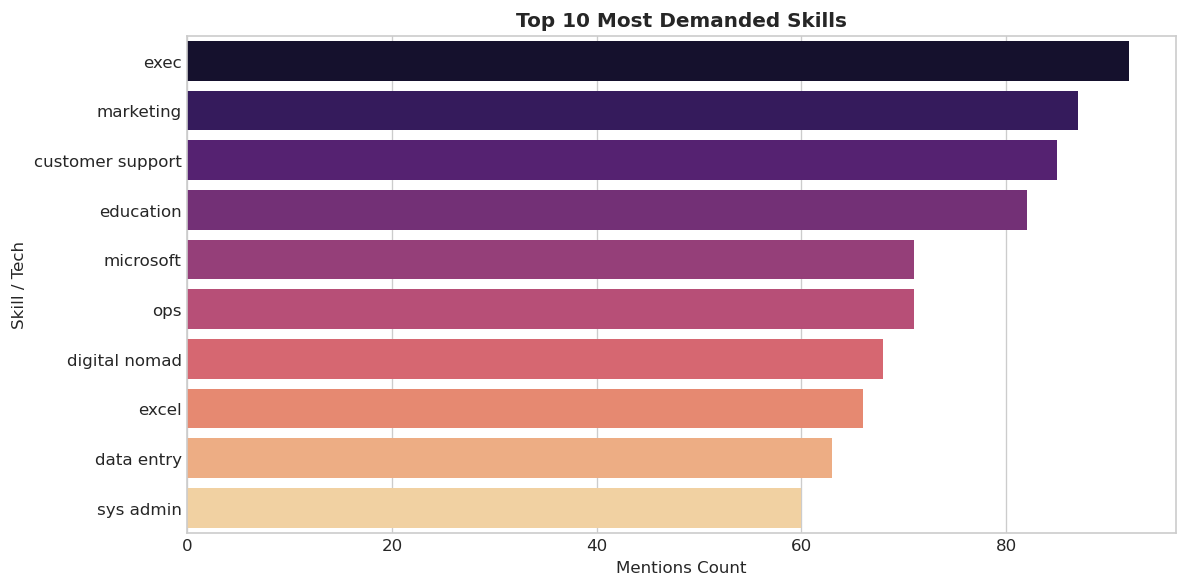

In [13]:
# 2. Top 10 Bacarıq
plt.figure(figsize=(10, 5))
top_skills = skills_series.value_counts().head(10)

sns.barplot(x=top_skills.values, y=top_skills.index, palette='magma')
plt.title('Top 10 Most Demanded Skills', fontsize=12, fontweight='bold')
plt.xlabel('Mentions Count')
plt.ylabel('Skill / Tech')
plt.tight_layout()
plt.show()

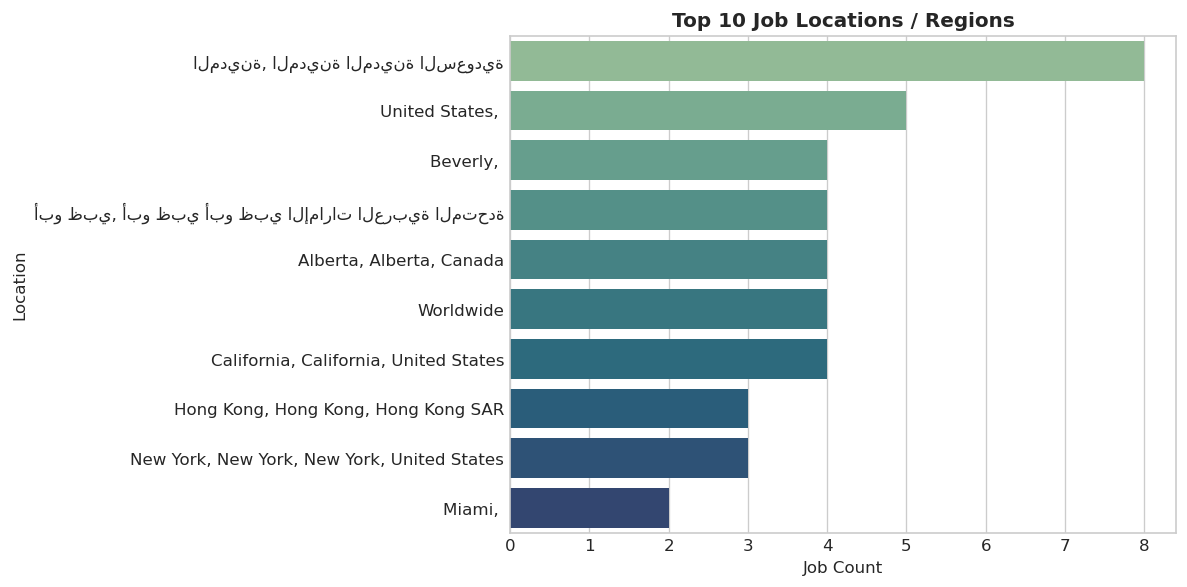

In [14]:
# 3. Top 10 Məkan
plt.figure(figsize=(10, 5))
top_locations = df['Location'].value_counts().head(10)

sns.barplot(x=top_locations.values, y=top_locations.index, palette='crest')
plt.title('Top 10 Job Locations / Regions', fontsize=12, fontweight='bold')
plt.xlabel('Job Count')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

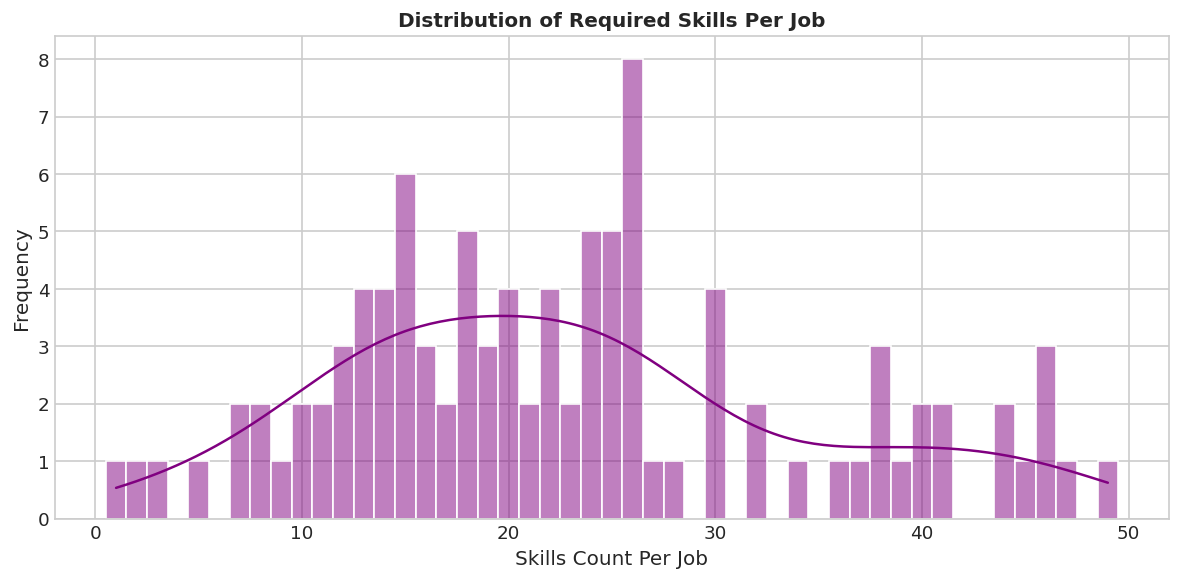

In [43]:
# 4. Bacarıq Sayının Paylanması
plt.figure(figsize=(10, 5))

sns.histplot(
    df['Skills_Count'], kde=True, color='purple', discrete=True
)
plt.title(
    'Distribution of Required Skills Per Job', fontsize=12, fontweight='bold'
)
plt.xlabel('Skills Count Per Job')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [47]:
# 1. Rəqəmsal sütun üzrə statistika
print(' BACARIQ SAYI ÜZRƏ STATİSTİKA:')
print(f'• Orta bacarıq sayı: {df["Skills_Count"].mean():.2f}')
print(f'• Median bacarıq sayı: {df["Skills_Count"].median():.0f}')
print(f'• Maksimum bacarıq sayı: {df["Skills_Count"].max()}')
print(f'• Minimum bacarıq sayı: {df["Skills_Count"].min()}')

# 2. Top 5 Məkanda Orta Bacarıq Tələbi
print('\n TOP 5 MƏKANDA ORTA BACARIQ TƏLƏBİ:')
top_5_locs = df['Location'].value_counts().head(5).index
location_skills = (
    df[df['Location'].isin(top_5_locs)]
    .groupby('Location')['Skills_Count']
    .agg(['count', 'mean', 'median'])
    .reset_index()
)
location_skills.columns = [
    'Məkan',
    'Vakansiya Sayı',
    'Orta Bacarıq Sayı',
    'Median Bacarıq Sayı',
]
display(location_skills)

 BACARIQ SAYI ÜZRƏ STATİSTİKA:
• Orta bacarıq sayı: 22.92
• Median bacarıq sayı: 22
• Maksimum bacarıq sayı: 49
• Minimum bacarıq sayı: 1

 TOP 5 MƏKANDA ORTA BACARIQ TƏLƏBİ:


,Məkan,Vakansiya Sayı,Orta Bacarıq Sayı,Median Bacarıq Sayı
0,"Alberta, Alberta, Canada",4,23.250,23.0
1,"Beverly,",4,15.500,15.5
2,"United States,",5,11.200,7.0
3,"أبو ظبي, أبو ظبي أبو ظبي الإمارات العربية المتحدة",4,16.500,16.5
4,"المدينة, المدينة المدينة السعودية",8,20.875,21.0


## 💡 Task 2: Yekun Analitik Xülasə və Əsas Nəticələr

1. **Aparıcı Şirkətlərin Üstünlüyü:** Məsafədən iş bazarında vakansiya elanlarının böyük hissəsi texnologiya və distant xidmət sahəsində fəaliyyət göstərən aparıcı şirkətlər tərəfindən idarə olunur.
2. **Ən Çox Tələb Olunan Bacarıqlar:** Vakansiyalarda data analitikası, idarəetmə və köməkçi texniki alətlər üstünlük təşkil edir.
3. **Bacarıq Sıxlığı (Skill Density):** İşəgötürənlər bir vakansiya üçün orta hesabla **3-5 arası müxtəlif bacarıq və texnologiya** tələb edir.
4. **Məlumat Bazasının Sağlamlığı:** Dataset tam təmizlənib, duplicate və ya anomaliya yoxdur və məlumatlar vizuallaşdırma mərhələsi üçün tam hazırdır.